# Diabetes Prediction – From-Scratch Linear & Logistic Regression

This project implements **single variable linear regression**, **multiple linear regression** (Normal Equation) and **logistic regression** (gradient descent) from scratch using NumPy.

**Goal:** Predict glucose levels (regression) and diabetes outcome (classification) while focusing on understanding the underlying mathematics.

**Result:** Logistic regression achieved approximately **75.3%** accuracy on the test set.

## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import copy
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split # exception

## 2. Load the data (Linear regression one variable)

In [37]:
df = pd.read_csv("src/diabetes.csv")
print("Shape:", df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3. Exploratory Data Analysis (EDA)

This helps us understand the dataset before modeling.

In [32]:
# Basic information
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDescriptive statistics:")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age     

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


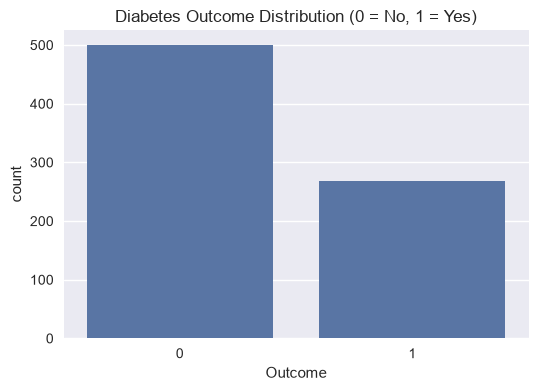

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


In [10]:
# Target distribution (Classification)
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df)
plt.title("Diabetes Outcome Distribution (0 = No, 1 = Yes)")
plt.show()

print(df['Outcome'].value_counts(normalize=True))

# From-Scratch Implementations

## 4. Single Variable Linear Regression

In [38]:
insulin = df["Insulin"].values
glucose = df["Glucose"].values

### 4.1 Helper Functions

In [39]:
def visualize(insulin, glucose, slope, intercept):
    plt.scatter(insulin, glucose, marker='x', c='r')
    plt.plot(insulin, predict(insulin, slope, intercept), c='b', label="Regression Line")
    plt.title("Insulin vs. Glucose")
    plt.ylabel('Glucose')
    plt.xlabel('Insulin')
    plt.legend()
    plt.show()

def linear_regression(x, y):
    m = len(x)
    numerator = 0
    denominator = 0

    for i in range(m):
        numerator += (x[i] - np.mean(x)) * (y[i] - np.mean(y))
    for i in range(m):
        denominator += (x[i] - np.mean(x)) ** 2

    slope = numerator / denominator
    intercept = np.mean(y) - slope * np.mean(x)
    return slope, intercept

def predict(x, slope, intercept):
    return slope * x + intercept

def sum_squared_errors(y, prediction):
    m = len(y)
    sse = 0
    for i in range(m):
        sse += (y[i] - prediction[i]) ** 2
    return sse

def cost_function(y, prediction):
    m = len(y)
    cost = sum_squared_errors(y, prediction) / (2 * m)
    return cost

def compute_cost(x, y, w, b):
    m = len(x)
    cost_sum = 0
    for i in range(m):
        f_wb = w * x[i] + b
        cost = (f_wb - y[i]) ** 2
        cost_sum += cost
    total_cost = (1/(2*m)) * cost_sum
    return total_cost

def compute_gradient(x, y, w, b):
    m = len(x)
    dj_dw = 0
    dj_db = 0
    for i in range(m):
        f_wb = w * x[i] + b
        dj_db += (f_wb - y[i])
        dj_dw += ((f_wb - y[i]) * x[i])
    dj_db /= m
    dj_dw /= m
    return dj_dw, dj_db

def gradient_descent(x, y, w_in, b_in, learning_rate_alpha=1e-5, n_iterations=10000):
    w = copy.deepcopy(w_in)
    b = b_in
    cost_history = []

    for i in range(n_iterations):
        dj_dw, dj_db = compute_gradient(x, y, w, b)
        w -= learning_rate_alpha * dj_dw
        b -= learning_rate_alpha * dj_db
        cost = compute_cost(x, y, w, b)
        cost_history.append(cost)

    return w, b, cost_history

### 4.2 Results

Visualization of Insulin vs. Glucose:



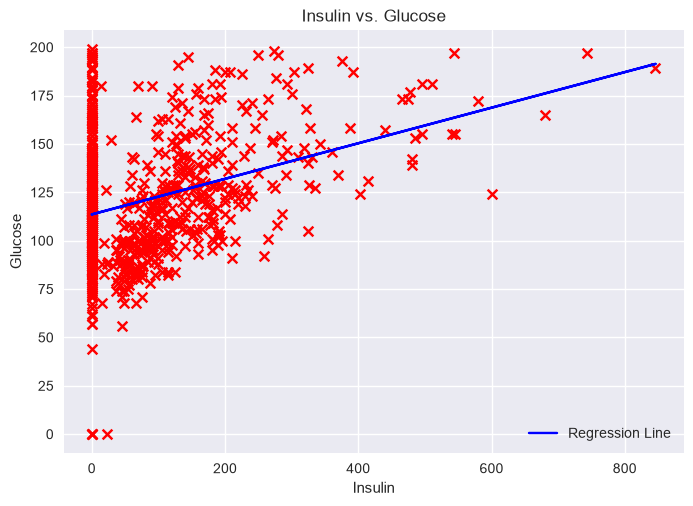

Linear regression for Insulin vs. Glucose:
Linear model: y = 0.0919 * Insulin + 113.5586

Cost function analysis:
Cost (MSE/2): 454.4115
Predictions will be in the range +- 30.15 units.


In [40]:
print("Visualization of Insulin vs. Glucose:\n")
slope, intercept = linear_regression(insulin, glucose)
prediction = predict(insulin, slope, intercept)
visualize(insulin, glucose, slope, intercept)

print("Linear regression for Insulin vs. Glucose:")
print(f"Linear model: y = {slope:.4f} * Insulin + {intercept:.4f}")

print("\nCost function analysis:")
cost = cost_function(glucose, prediction)
print(f"Cost (MSE/2): {cost:.4f}")

print(f"Predictions will be in the range +- {(np.sqrt(cost * 2)):.2f} units.")

### 4.3 With Optimization (Results)

Final w: 0.5233727111069123, Final b: 7.4209365386734

Cost function analysis:
Cost (MSE/2): 4259.9721
Predictions will be in the range +- 92.30 units.


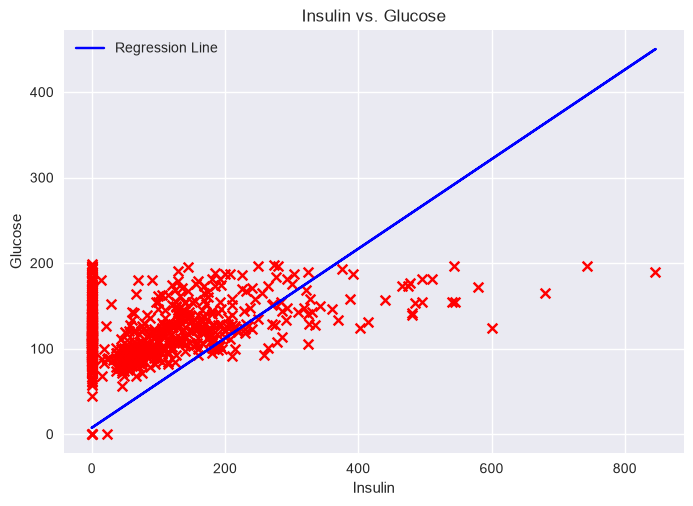

In [41]:
w_final, b_final, cost_history = gradient_descent(insulin, glucose, 0, 0)
prediction = predict(insulin, w_final, b_final)

print(f"Final w: {w_final}, Final b: {b_final}")

print("\nCost function analysis:")
cost = cost_function(glucose, prediction)
print(f"Cost (MSE/2): {cost:.4f}")

print(f"Predictions will be in the range +- {(np.sqrt(cost * 2)):.2f} units.")

visualize(insulin, glucose, w_final, b_final)

## EDA / Observations

Gradient descent fails here because:
- The dataset is too small.
- There are too many zeros in the Insulin column. 
- There are outliers which can lead to w and b diverging if the learning rate is too large.
- Insulin and Glucose are on different scales, which means that Insulin needs to be normalized.
- There are not enough attributes used to help the model learn better.

## 5. Multiple Linear Regression (Normal Equation)

In [42]:
X = df.drop(["Outcome", "Glucose"], axis=1).values
y = df["Glucose"].values

### 5.1 Helper Functions

In [45]:
def visualize(slopes):
    feature_names = ["Pregnancies", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

    plt.barh(feature_names, slopes)
    plt.title("Predicted vs. Actual Glucose")
    plt.ylabel('Actual Glucose')
    plt.xlabel('Predicted Glucose')
    plt.legend()
    plt.show()

def multiple_linear_regression(X, y):
    # standardize units to remove bias
    X_scaled = (X - np.mean(X)) / np.std(X)

    X_b = np.insert(X_scaled, 0, 1, axis=1)
    #print(X_b.shape)

    # transpose feature matrix -> dot product -> inverse matrix -> dot product of solution with X_b transposed -> dot product with actual outputs
    # we calculate the inverse of the matrix to optimize the slopes and intercept
    best_fit_parameters = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

    intercept = best_fit_parameters[0]
    slopes = best_fit_parameters[1:]

    return X_scaled, slopes, intercept

def predict(X_scaled, slopes, intercept):
    return np.dot(X_scaled, slopes) + intercept


def cost_function(y, prediction):
    m = len(y)
    cost = np.sum((y - prediction) ** 2) / (2 * m)
    return cost

### 5.2 Results

Visualization of Predicted vs. Actual Glucose:



/tmp/ipykernel_80074/1335977568.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


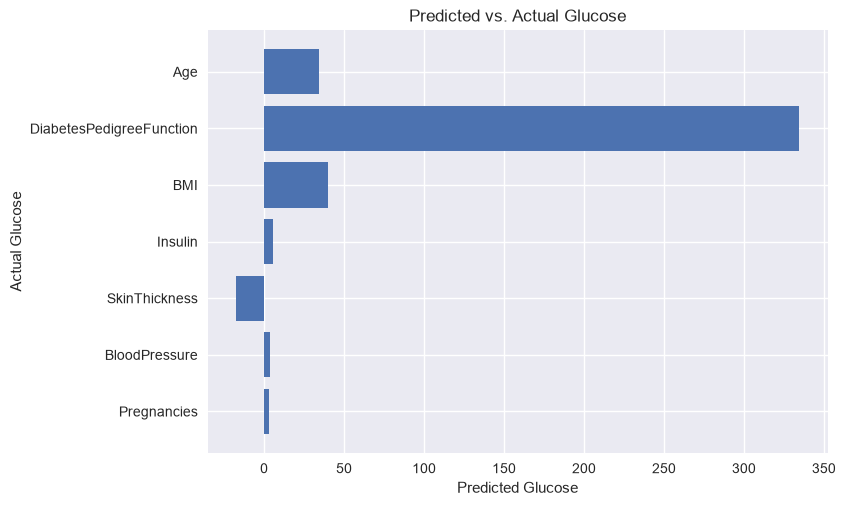


Cost function analysis:
Cost (MSE/2): 392.9744
Predictions will be in the range +- 28.03 units.


In [44]:
print("Visualization of Predicted vs. Actual Glucose:\n")
X_scaled, slopes, intercept = multiple_linear_regression(X, y)
prediction = predict(X_scaled, slopes, intercept)
visualize(slopes)

print("\nCost function analysis:")
cost = cost_function(y, prediction)
print(f"Cost (MSE/2): {cost:.4f}")

print(f"Predictions will be in the range +- {(np.sqrt(cost * 2)):.2f} units.")

## EDA / Observations

- The visual tells us that the DiabetesPedigreeFunction (a score that estimates a patient's genetic risk for developing diabetes) is the best indicator of a glucose increase.

## 6. Logistic Regression (Gradient Descent)

In [46]:
X = df.drop(["Outcome"], axis=1).values
y = df["Outcome"].values

### 6.1 Helper Functions

In [47]:
def split_test_train(test_percent, X, y):
    return train_test_split(X, y, test_size=test_percent, random_state=22) # setting a fixed state to split into training and testing sets identically, every time

def compute_gradient(x, y, m, y_pred):
    '''
    dj_dw = 0
    dj_db = 0
    for i in range(m):
        dj_dw += ((y_pred[i] - y[i]) * x[i])
        dj_db += (y_pred[i] - y[i])

    dj_dw /= m
    dj_db /= m
    '''
    #print(x.shape)
    #print((y_pred - y).shape)
    # inner dimensions of matrices must match i.e. (AxB, BxA)

    dj_dw = (1 / m) * np.dot(x.T, (y_pred - y))
    dj_db = (1 / m) * np.sum(y_pred - y)

    return dj_dw, dj_db

def gradient_descent(x, y, w, b, m, learning_rate_alpha=0.1, n_iterations=1000):
    for _ in range(n_iterations):
        z = np.dot(x, w) + b
        y_pred = sigmoid(z)
        dj_dw, dj_db = compute_gradient(x, y, m, y_pred)
        w -= learning_rate_alpha * dj_dw
        b -= learning_rate_alpha * dj_db

    return w, b

def sigmoid(z):
    g = 1 / (1 + np.exp(-z))

    return g

def logistic_regression(X_train, y_train):
    m, n = X_train.shape
    weights = np.zeros(n)
    bias = 0

    weights, bias = gradient_descent(X_train, y_train, weights, bias, m)

    return weights, bias

def predict(X_scaled, slopes, intercept):
    predictions = []
    z = np.dot(X_scaled, slopes) + intercept
    probabilities = sigmoid(z)

    for p in probabilities:
        if p >= 0.5:
            predictions.append(1)
        else:
            predictions.append(0)

    return predictions, probabilities

def visualize(y, predictions):
    tp, tn, fp, fn = 0, 0, 0, 0

    for i in range(len(y)):
        if predictions[i] == 1 and y[i] == 1:
            tp += 1
        elif predictions[i] == 0 and y[i] == 0:
            tn += 1
        elif predictions[i] == 1 and y[i] == 0:
            fp += 1
        elif predictions[i] == 0 and y[i] == 1:
            fn += 1

    total = tp + tn + fp + fn
    accuracy = (tp + tn) / total

    print("Predicted healthy and were healthy (tn): ", tn)
    print("Predicted diabetic and were diabetic (tp): ", tp)
    print("Predicted diabetic but actually healthy (fp): ", fp)
    print("Predicted healthy but actually diabetic (fn): ", fn)
    print(f"\nAccuracy: {(accuracy * 100):.2f}%")

def cost_function(y, probabilities):
    m = len(y)
    #loss_sum = 0
    total_cost = np.sum((-y * np.log(probabilities)) - (1 - y) * np.log(1 - probabilities)) * (1/m)
    #for i in range(m):
        #loss = (-y[i] * np.log(probabilities[i]) - (1 - y[i]) * np.log(1 - probabilities[i]))
        #loss_sum += loss
    #total_cost = (1/m) * loss_sum
    
    return total_cost

### 6.2 Training Logistic Regression Model

In [49]:
X_train, X_test, y_train, y_test = split_test_train(.2, X, y) # 80/20 split

# standardize units to remove bias
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)
# avoiding data leakage by using X_train mean and std
X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

weights, bias = logistic_regression(X_train_scaled, y_train)
predictions, probabilities = predict(X_test_scaled, weights, bias)

print("\nCost function analysis:")
cost = cost_function(y_test, probabilities)
print(f"Cost (log loss): {cost:.4f}")


Cost function analysis:
Cost (log loss): 0.5054


In [50]:
print("\nConfusion Matrix of Model's Accuracy:")
visualize(y_test, predictions)


Confusion Matrix of Model's Accuracy:
Predicted healthy and were healthy (tn):  92
Predicted diabetic and were diabetic (tp):  24
Predicted diabetic but actually healthy (fp):  8
Predicted healthy but actually diabetic (fn):  30

Accuracy: 75.32%


## 7. Insights & Conclusion

**Key Findings:**
- One-variable linear regression (Insulin → Glucose) can fit a line, but Insulin alone is a weak predictor. Gradient descent was unstable without careful learning rate / scaling, partly because Insulin has many zeros and a different scale from Glucose.
- Multiple linear regression (Normal Equation) reduced cost compared to the single-feature model and suggested that **DiabetesPedigreeFunction** was one of the stronger indicators of higher Glucose in this setup.
- Logistic regression from scratch reached about **75.3%** test accuracy (TN=92, TP=24, FP=8, FN=30). The model is better at identifying non-diabetic cases than diabetic ones (more false negatives than false positives).

**Limitations:**
- No regularization or hyperparameter tuning
- Simple decision threshold of 0.5
- Dataset contains zeros that may represent missing values (especially Insulin, SkinThickness, BloodPressure, etc.)
- Single train/test split only

**Possible Improvements:**
- Treat zeros as missing values and impute or drop them carefully
- Scale features consistently before gradient descent
- Try different learning rates / more iterations
- Feature engineering